In [27]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, StackingClassifier, ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


def tune_3_methods(model_name, base_est, param_grid, param_dist, optuna_space,
                   X_tr, y_tr, X_te, y_te, cv, scoring='f1_weighted',
                   n_iter=15, n_trials=25):
    """
    Подбирает гиперпараметры тремя методами и возвращает лучшую модель.

    base_est    — экземпляр модели с зафиксированными служебными параметрами
    param_grid  — dict для GridSearchCV (небольшая сетка, полный перебор)
    param_dist  — dict для RandomizedSearchCV (шире, случайная выборка)
    optuna_space— dict {param: ('int', lo, hi) |
                               ('float', lo, hi[, log=True]) |
                               ('cat', [values])}
    """
    results = {}

    # 1. GridSearchCV
    gs = GridSearchCV(clone(base_est), param_grid, cv=cv, scoring=scoring, n_jobs=-1)
    gs.fit(X_tr, y_tr)
    results['GridSearchCV'] = {'score': gs.best_score_, 'params': gs.best_params_,
                               'model': gs.best_estimator_}

    # 2. RandomizedSearchCV
    rs = RandomizedSearchCV(clone(base_est), param_dist, n_iter=n_iter, cv=cv,
                            scoring=scoring, n_jobs=-1, random_state=42)
    rs.fit(X_tr, y_tr)
    results['RandomizedSearchCV'] = {'score': rs.best_score_, 'params': rs.best_params_,
                                     'model': rs.best_estimator_}

    # 3. Optuna
    def objective(trial):
        p = {}
        for k, spec in optuna_space.items():
            if spec[0] == 'int':
                p[k] = trial.suggest_int(k, spec[1], spec[2])
            elif spec[0] == 'float':
                p[k] = trial.suggest_float(k, spec[1], spec[2],
                                           log=len(spec) > 3 and spec[3])
            elif spec[0] == 'cat':
                p[k] = trial.suggest_categorical(k, spec[1])
        return cross_val_score(clone(base_est).set_params(**p),
                               X_tr, y_tr, cv=cv, scoring=scoring).mean()

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    opt_model = clone(base_est).set_params(**study.best_params)
    opt_model.fit(X_tr, y_tr)
    results['Optuna'] = {'score': study.best_value, 'params': study.best_params,
                         'model': opt_model}

    # Сравнительная таблица
    score_col = f'CV {scoring}'
    cmp = pd.DataFrame([
        {'Метод': m,
         score_col: round(r['score'], 4),
         'Лучшие параметры': ', '.join(f"{k}={round(v,4) if isinstance(v,float) else v}"
                                        for k, v in r['params'].items())}
        for m, r in results.items()
    ]).set_index('Метод')
    display(cmp.style
            .highlight_max(subset=[score_col], color='#b7f0b1')
            .set_caption(f'{model_name} — сравнение методов подбора'))

    # Лучший метод
    best_method = max(results, key=lambda k: results[k]['score'])
    best_model = results[best_method]['model']
    print(f"  Лучший метод: {best_method}  (CV {scoring}={results[best_method]['score']:.4f})")

    _, res = eval_model(f'{model_name} ({best_method})', best_model, X_tr, y_tr, X_te, y_te)

    return best_model, res, best_method, {m: r['score'] for m, r in results.items()}


## Сильные и слабые стороны моделей

| Модель | Сильные стороны | Слабые стороны |
|--------|----------------|----------------|
| **DecisionTree** | Интерпретируем, быстрый, не требует масштабирования | Сильно переобучается без ограничений; нестабилен (маленькое изменение данных → другое дерево) |
| **Bagging** | Снижает дисперсию за счёт усреднения; устойчив к выбросам | Не снижает смещение; медленнее одного дерева |
| **RandomForest** | Хорошо на табличных данных; устойчив к переобучению; параллелится | Хуже бустинга на несбалансированных данных; тяжелее по памяти |
| **GradientBoosting** | Высокое качество; хорошо на несбалансированных классах | Медленное обучение; много гиперпараметров; чувствителен к выбросам |
| **AdaBoost** | Прост в настройке; нет оверфита при правильном числе итераций | Очень чувствителен к шуму и выбросам; слабее современного бустинга |
| **ExtraTrees** | Быстрее RF (случайные пороги); хорошая регуляризация | Чуть хуже RF по качеству; случайность может пропустить важные признаки |
| **Stacking** | Комбинирует разные модели → снижает и смещение, и дисперсию | Долгое обучение (CV на каждой модели); риск переобучения метамодели |
| **CatBoost** | Нативная работа с категориальными признаками; устойчив к утечке | Медленнее LightGBM; тяжелее для продакшна |
| **XGBoost** | Зрелая библиотека; много опций регуляризации | Требует тщательного подбора гиперпараметров; медленнее LightGBM |
| **LightGBM** | Быстрый (leaf-wise рост дерева); эффективен на больших данных | Склонен к переобучению на маленьких датасетах; leaf-wise менее стабилен |

In [28]:
# Датасет студентов — задача классификации
# Target: 0 = Dropout (отчислен), 1 = Enrolled (учится), 2 = Graduate (окончил)
df = pd.read_csv('../lab3/stud_end.csv')
print('Размер датасета:', df.shape)
print()
print('Распределение классов (дисбаланс!):')
vc = df['Target'].value_counts().rename({0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'})
print(vc)
df.head()

Размер датасета: (3171, 97)

Распределение классов (дисбаланс!):
Target
Graduate    1946
Enrolled     654
Dropout      571
Name: count, dtype: int64


,Application order,Daytime/evening attendance\t,Previous qualification (grade),Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,...,Father's occupation_2,Father's occupation_3,Father's occupation_4,Father's occupation_5,Father's occupation_6,Father's occupation_7,Father's occupation_8,Father's occupation_9,Father's occupation_10,Father's occupation_Other
0,1,1,160.0,142.5,1,0,0,0,1,0,...,False,True,False,False,False,False,False,False,False,False
1,2,1,122.0,119.6,1,0,0,1,0,0,...,False,True,False,False,False,False,False,False,False,False
2,1,1,142.0,128.4,1,0,0,1,0,1,...,False,False,False,False,False,False,False,False,True,False
3,3,1,137.0,129.3,0,0,0,1,0,1,...,False,False,False,False,False,False,False,True,False,False
4,1,1,138.0,123.0,1,0,1,0,0,0,...,False,False,False,False,False,True,False,False,False,False


In [29]:

TARGET = 'Target'

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'StratifiedKFold: {skf.n_splits} folds')

best_params_all = {}


Train: (2219, 96), Val: (476, 96), Test: (476, 96)
StratifiedKFold: 5 folds


In [30]:
# Вспомогательная функция: обучает модель и возвращает метрики на train и test
# F1 weighted — учитывает дисбаланс: взвешивает метрику каждого класса по его размеру
def eval_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    res = {}
    for split, X, y in [('train', X_tr, y_tr), ('test', X_te, y_te)]:
        pred = model.predict(X)
        res[split] = {
            'Accuracy':  accuracy_score(y, pred),
            'F1':        f1_score(y, pred, average='weighted'),
            'Precision': precision_score(y, pred, average='weighted'),
            'Recall':    recall_score(y, pred, average='weighted'),
        }
    print(f"{name:40s}  Train F1={res['train']['F1']:.4f}  Test F1={res['test']['F1']:.4f}")
    return model, res

all_results = {}  # сюда складываем результаты всех моделей для итоговой таблицы

## 3.1 DecisionTreeClassifier

In [31]:

dt_base = DecisionTreeClassifier(random_state=42)
_, res = eval_model('DT (base)', dt_base, X_train, y_train, X_test, y_test)
all_results['DT (base)'] = res

print("\n=== DecisionTree — подбор гиперпараметров ===")

dt_best, res, dt_best_method, dt_scores = tune_3_methods(
    model_name='DecisionTree',
    base_est=DecisionTreeClassifier(random_state=42),
    param_grid={
        'max_depth':        [5, 10, 15],
        'min_samples_leaf': [1, 5, 20],
        'class_weight':     [None, 'balanced'],
    },
    param_dist={
        'max_depth':         [5, 10, 15, None],
        'min_samples_split': [2, 10, 50],
        'min_samples_leaf':  [1, 5, 20],
        'class_weight':      [None, 'balanced'],
    },
    optuna_space={
        'max_depth':         ('int', 3, 20),
        'min_samples_split': ('int', 2, 50),
        'min_samples_leaf':  ('int', 1, 20),
        'class_weight':      ('cat', [None, 'balanced']),
    },
    X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test,
    cv=skf, scoring='f1_weighted', n_iter=15, n_trials=25,
)

all_results[f'DT ({dt_best_method})'] = res
best_params_all['DecisionTree'] = {'лучший метод': dt_best_method, 'CV F1': dt_scores}


DT (base)                                 Train F1=1.0000  Test F1=0.6932

=== DecisionTree — подбор гиперпараметров ===


,CV f1_weighted,Лучшие параметры
Метод,,
GridSearchCV,0.699600,"class_weight=None, max_depth=10, min_samples_leaf=20"
RandomizedSearchCV,0.699600,"min_samples_split=10, min_samples_leaf=20, max_depth=None, class_weight=None"
Optuna,0.712700,"max_depth=7, min_samples_split=49, min_samples_leaf=19, class_weight=None"


  Лучший метод: Optuna  (CV f1_weighted=0.7127)
DecisionTree (Optuna)                     Train F1=0.7580  Test F1=0.7146


## 4. Визуализация дерева решений

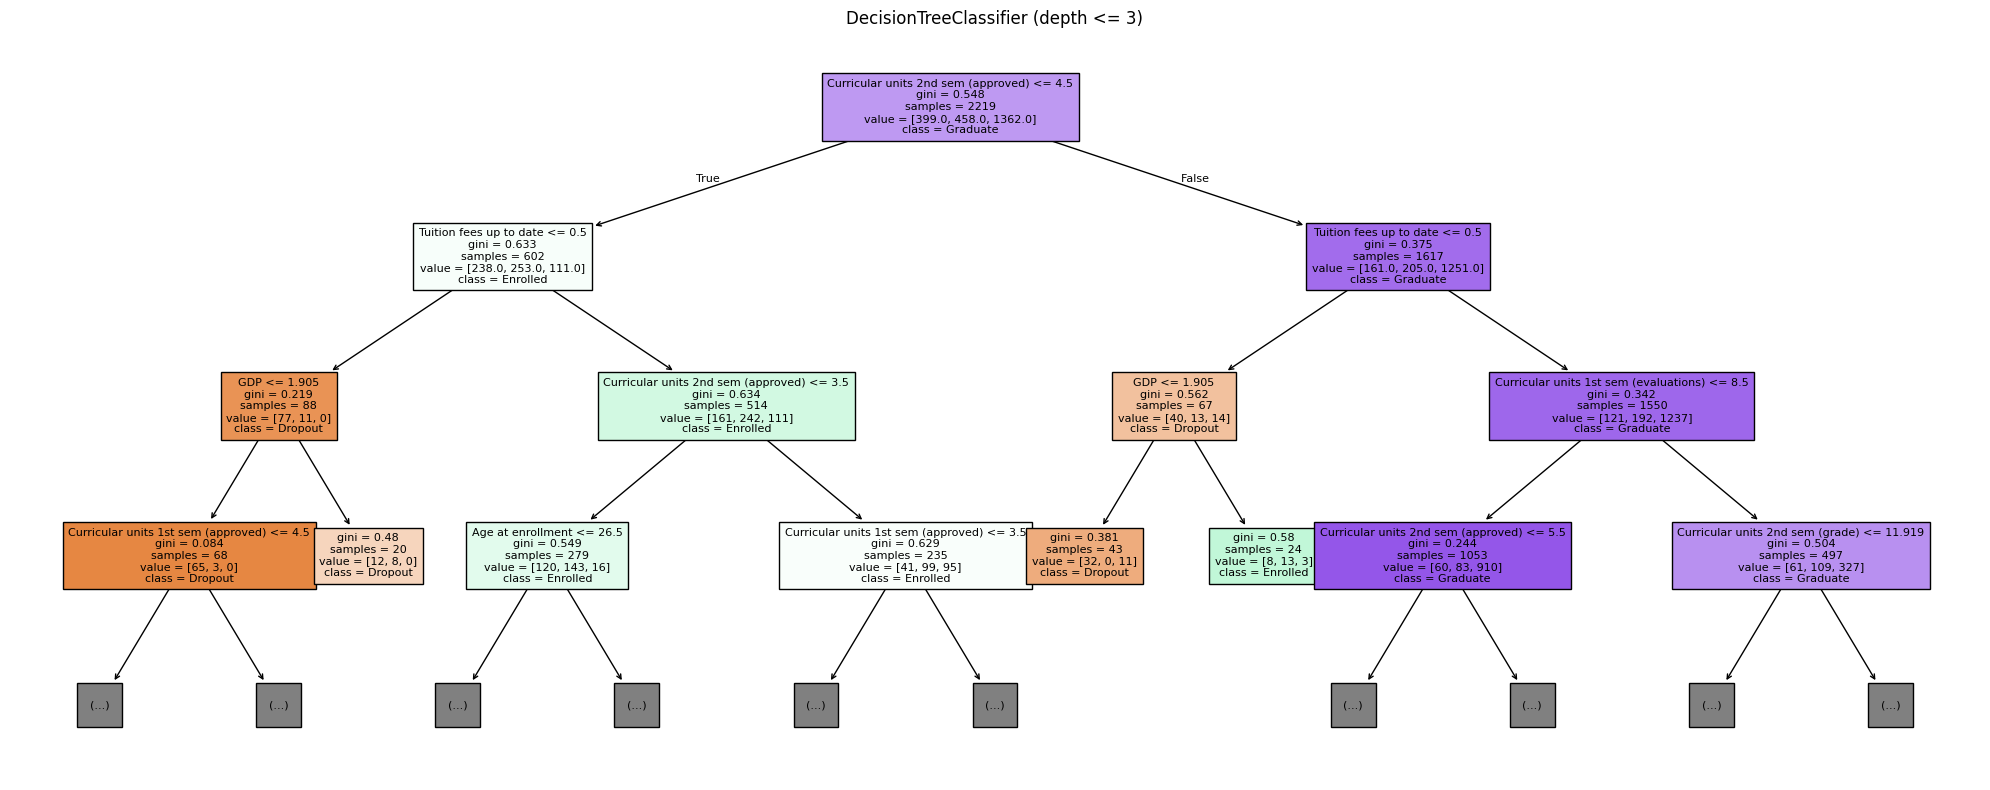

|--- Curricular units 2nd sem (approved) <= 4.50
|   |--- Tuition fees up to date <= 0.50
|   |   |--- GDP <= 1.90
|   |   |   |--- Curricular units 1st sem (approved) <= 4.50
|   |   |   |   |--- class: 0
|   |   |   |--- Curricular units 1st sem (approved) >  4.50
|   |   |   |   |--- class: 0
|   |   |--- GDP >  1.90
|   |   |   |--- class: 0
|   |--- Tuition fees up to date >  0.50
|   |   |--- Curricular units 2nd sem (approved) <= 3.50
|   |   |   |--- Age at enrollment <= 26.50
|   |   |   |   |--- Curricular units 1st sem (approved) <= 4.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- Curricular units 1st sem (approved) >  4.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Age at enrollment >  26.50
|   |   |   |   |--- class: 0
|   |   |--- Curricular units 2nd sem (approved) >  3.50
|   |   |   |--- Curricular units 1st sem (approved) <= 3.50
|   |   |   |   |--- class: 1
|   |   |   |--- Curricular units 1st sem (approved)

In [32]:
# max_depth=3 в plot_tree — только для читаемости, само дерево не обрезаем
class_names = ['Dropout', 'Enrolled', 'Graduate']

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_best, max_depth=3,
    feature_names=X_train.columns,
    class_names=class_names,
    filled=True, ax=ax, fontsize=8
)
plt.title('DecisionTreeClassifier (depth <= 3)')
plt.tight_layout()
plt.show()

# Текстовые правила — по ним можно объяснить решение дерева на защите
print(export_text(dt_best, feature_names=list(X_train.columns), max_depth=4))

## 3.2 Ансамбли sklearn

In [33]:
# Bagging — обучает N деревьев на случайных подвыборках, голосование большинством
# RandomForest — Bagging + при каждом сплите рассматривает только sqrt(n_features) признаков
# GradientBoosting — деревья строятся последовательно, каждое исправляет ошибки предыдущего
# AdaBoost — увеличивает вес объектов, на которых ошиблось предыдущее дерево
# Stacking: 3 разнородных модели — дерево (RF), метод опорных векторов (SVC), k ближайших соседей
# SVC и KNN нуждаются в масштабировании → оборачиваем в Pipeline со StandardScaler
sklearn_classifiers = [
    ('Bagging',          BaggingClassifier(n_estimators=50, random_state=42, n_jobs=-1)),
    ('RandomForest',     RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')),
    ('GradientBoosting', GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ('AdaBoost',         AdaBoostClassifier(n_estimators=200, random_state=42)),
    ('Stacking',         StackingClassifier(
        estimators=[
            ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
            ('svc', Pipeline([('sc', StandardScaler()), ('m', SVC(kernel='rbf', probability=True, random_state=42))])),
            ('knn', Pipeline([('sc', StandardScaler()), ('m', KNeighborsClassifier(n_neighbors=10, n_jobs=-1))])),
        ],
        final_estimator=LogisticRegression(max_iter=1000),
        cv=5, n_jobs=-1,
    )),
]

for name, model in sklearn_classifiers:
    _, res = eval_model(name, model, X_train, y_train, X_test, y_test)
    all_results[name] = res


Bagging                                   Train F1=0.9995  Test F1=0.7102
RandomForest                              Train F1=1.0000  Test F1=0.7327
GradientBoosting                          Train F1=0.9133  Test F1=0.7359
AdaBoost                                  Train F1=0.7336  Test F1=0.7214
Stacking                                  Train F1=0.9941  Test F1=0.7300


In [34]:

print("=== RandomForest — подбор гиперпараметров ===")

rf_best, res, rf_best_method, rf_scores = tune_3_methods(
    model_name='RandomForest',
    base_est=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={
        'n_estimators': [100, 200],
        'max_depth':    [10, 20, None],
        'class_weight': [None, 'balanced'],
    },
    param_dist={
        'n_estimators':      [100, 200, 300, 500],
        'max_depth':         [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'max_features':      ['sqrt', 'log2'],
        'class_weight':      [None, 'balanced'],
    },
    optuna_space={
        'n_estimators':      ('int', 50,  500),
        'max_depth':         ('int', 5,   30),
        'min_samples_split': ('int', 2,   20),
        'max_features':      ('cat', ['sqrt', 'log2']),
        'class_weight':      ('cat', [None, 'balanced']),
    },
    X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test,
    cv=skf, scoring='f1_weighted', n_iter=15, n_trials=25,
)

all_results[f'RandomForest ({rf_best_method})'] = res
best_params_all['RandomForest'] = {'лучший метод': rf_best_method, 'CV F1': rf_scores}

print("\n=== GradientBoosting — подбор гиперпараметров ===")

gbr_best, res, gbr_best_method, gbr_scores = tune_3_methods(
    model_name='GradientBoosting',
    base_est=GradientBoostingClassifier(random_state=42),
    param_grid={
        'n_estimators':  [100, 200],
        'max_depth':     [3, 5],
        'learning_rate': [0.05, 0.1],
    },
    param_dist={
        'n_estimators':  [100, 200, 300],
        'max_depth':     [3, 4, 5],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample':     [0.7, 0.8, 1.0],
    },
    optuna_space={
        'n_estimators':  ('int',   100, 400),
        'max_depth':     ('int',   2,   6),
        'learning_rate': ('float', 0.01, 0.3, True),
        'subsample':     ('float', 0.6,  1.0),
    },
    X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test,
    cv=skf, scoring='f1_weighted', n_iter=15, n_trials=25,
)

all_results[f'GradientBoosting ({gbr_best_method})'] = res
best_params_all['GradientBoosting'] = {'лучший метод': gbr_best_method, 'CV F1': gbr_scores}

print("\n=== Bagging — подбор гиперпараметров ===")

bag_best, res, bag_best_method, bag_scores = tune_3_methods(
    model_name='Bagging',
    base_est=BaggingClassifier(random_state=42, n_jobs=-1),
    param_grid={
        'n_estimators': [50, 100],
        'max_samples':  [0.7, 1.0],
        'max_features': [0.7, 1.0],
    },
    param_dist={
        'n_estimators': [50, 100, 200],
        'max_samples':  [0.6, 0.7, 0.8, 1.0],
        'max_features': [0.6, 0.7, 0.8, 1.0],
    },
    optuna_space={
        'n_estimators': ('int',   30,  200),
        'max_samples':  ('float', 0.5, 1.0),
        'max_features': ('float', 0.5, 1.0),
    },
    X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test,
    cv=skf, scoring='f1_weighted', n_iter=15, n_trials=20,
)

all_results[f'Bagging ({bag_best_method})'] = res
best_params_all['Bagging'] = {'лучший метод': bag_best_method, 'CV F1': bag_scores}

print("\n=== AdaBoost — подбор гиперпараметров ===")

ada_best, res, ada_best_method, ada_scores = tune_3_methods(
    model_name='AdaBoost',
    base_est=AdaBoostClassifier(random_state=42),
    param_grid={
        'n_estimators':  [100, 200],
        'learning_rate': [0.5, 1.0, 2.0],
    },
    param_dist={
        'n_estimators':  [100, 200, 300],
        'learning_rate': [0.1, 0.5, 1.0, 2.0],
    },
    optuna_space={
        'n_estimators':  ('int',   50,  300),
        'learning_rate': ('float', 0.01, 3.0, True),
    },
    X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test,
    cv=skf, scoring='f1_weighted', n_iter=12, n_trials=20,
)

all_results[f'AdaBoost ({ada_best_method})'] = res
best_params_all['AdaBoost'] = {'лучший метод': ada_best_method, 'CV F1': ada_scores}


=== RandomForest — подбор гиперпараметров ===


,CV f1_weighted,Лучшие параметры
Метод,,
GridSearchCV,0.734800,"class_weight=balanced, max_depth=10, n_estimators=100"
RandomizedSearchCV,0.731400,"n_estimators=200, min_samples_split=10, max_features=sqrt, max_depth=None, class_weight=balanced"
Optuna,0.735700,"n_estimators=163, max_depth=13, min_samples_split=8, max_features=log2, class_weight=balanced"


  Лучший метод: Optuna  (CV f1_weighted=0.7357)
RandomForest (Optuna)                     Train F1=0.9190  Test F1=0.7269

=== GradientBoosting — подбор гиперпараметров ===


,CV f1_weighted,Лучшие параметры
Метод,,
GridSearchCV,0.733700,"learning_rate=0.05, max_depth=3, n_estimators=200"
RandomizedSearchCV,0.740500,"subsample=0.7, n_estimators=200, max_depth=3, learning_rate=0.05"
Optuna,0.742900,"n_estimators=182, max_depth=2, learning_rate=0.1235, subsample=0.8528"


  Лучший метод: Optuna  (CV f1_weighted=0.7429)
GradientBoosting (Optuna)                 Train F1=0.8440  Test F1=0.7295

=== Bagging — подбор гиперпараметров ===


,CV f1_weighted,Лучшие параметры
Метод,,
GridSearchCV,0.725400,"max_features=0.7, max_samples=0.7, n_estimators=100"
RandomizedSearchCV,0.724900,"n_estimators=50, max_samples=0.8, max_features=0.6"
Optuna,0.730500,"n_estimators=141, max_samples=0.5183, max_features=0.6868"


  Лучший метод: Optuna  (CV f1_weighted=0.7305)
Bagging (Optuna)                          Train F1=0.9668  Test F1=0.7151

=== AdaBoost — подбор гиперпараметров ===


,CV f1_weighted,Лучшие параметры
Метод,,
GridSearchCV,0.715100,"learning_rate=1.0, n_estimators=200"
RandomizedSearchCV,0.724300,"n_estimators=300, learning_rate=1.0"
Optuna,0.725500,"n_estimators=191, learning_rate=1.6282"


  Лучший метод: Optuna  (CV f1_weighted=0.7255)
AdaBoost (Optuna)                         Train F1=0.7660  Test F1=0.7036


## 3.3 Градиентный бустинг: CatBoost / XGBoost / LightGBM

In [35]:
# Специализированные библиотеки бустинга — быстрее и точнее sklearn GradientBoosting
# eval_metric='mlogloss' у XGBoost — многоклассовая кросс-энтропия (нужно указать явно)
boost_classifiers = [
    ('CatBoost', CatBoostClassifier(iterations=500, random_state=42, verbose=0)),
    ('XGBoost',  XGBClassifier(
        n_estimators=500, random_state=42, n_jobs=-1,
        verbosity=0, eval_metric='mlogloss'
    )),
    ('LightGBM', LGBMClassifier(n_estimators=500, random_state=42, n_jobs=-1, verbose=-1)),
]

for name, model in boost_classifiers:
    _, res = eval_model(name, model, X_train, y_train, X_test, y_test)
    all_results[name] = res

CatBoost                                  Train F1=0.9873  Test F1=0.7329
XGBoost                                   Train F1=1.0000  Test F1=0.7174
LightGBM                                  Train F1=1.0000  Test F1=0.7269


In [36]:

# Базовые прогоны
for name, model in [
    ('CatBoost', CatBoostClassifier(iterations=500, random_state=42, verbose=0)),
    ('XGBoost',  XGBClassifier(n_estimators=500, random_state=42, n_jobs=-1,
                               verbosity=0, eval_metric='mlogloss')),
    ('LightGBM', LGBMClassifier(n_estimators=500, random_state=42, n_jobs=-1, verbose=-1)),
]:
    _, res = eval_model(name, model, X_train, y_train, X_test, y_test)
    all_results[name] = res

# ── CatBoost ──
print("\n=== CatBoost — подбор гиперпараметров ===")
cat_best, res, cat_best_method, cat_scores = tune_3_methods(
    model_name='CatBoost',
    base_est=CatBoostClassifier(random_state=42, verbose=0),
    param_grid={
        'iterations':    [300, 500],
        'depth':         [4, 6],
        'learning_rate': [0.03, 0.1],
    },
    param_dist={
        'iterations':    [200, 300, 500, 700],
        'depth':         [4, 5, 6, 7, 8],
        'learning_rate': [0.01, 0.03, 0.1],
        'l2_leaf_reg':   [1, 3, 5],
    },
    optuna_space={
        'iterations':    ('int',   200, 800),
        'depth':         ('int',   3,   8),
        'learning_rate': ('float', 0.01, 0.3, True),
        'l2_leaf_reg':   ('float', 1.0, 10.0, True),
    },
    X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test,
    cv=skf, scoring='f1_weighted', n_iter=15, n_trials=25,
)
all_results[f'CatBoost ({cat_best_method})'] = res
best_params_all['CatBoost'] = {'лучший метод': cat_best_method, 'CV F1': cat_scores}

# ── XGBoost ──
print("\n=== XGBoost — подбор гиперпараметров ===")
xgb_best, res, xgb_best_method, xgb_scores = tune_3_methods(
    model_name='XGBoost',
    base_est=XGBClassifier(random_state=42, n_jobs=-1, verbosity=0, eval_metric='mlogloss'),
    param_grid={
        'n_estimators':  [200, 400],
        'max_depth':     [4, 6],
        'learning_rate': [0.05, 0.1],
    },
    param_dist={
        'n_estimators':     [200, 400, 600],
        'max_depth':        [3, 5, 7],
        'learning_rate':    [0.01, 0.05, 0.1, 0.2],
        'subsample':        [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
    },
    optuna_space={
        'n_estimators':     ('int',   200, 800),
        'max_depth':        ('int',   3,   9),
        'learning_rate':    ('float', 0.01, 0.3, True),
        'subsample':        ('float', 0.6,  1.0),
        'colsample_bytree': ('float', 0.6,  1.0),
    },
    X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test,
    cv=skf, scoring='f1_weighted', n_iter=15, n_trials=30,
)
all_results[f'XGBoost ({xgb_best_method})'] = res
best_params_all['XGBoost'] = {'лучший метод': xgb_best_method, 'CV F1': xgb_scores}

# ── LightGBM ──
print("\n=== LightGBM — подбор гиперпараметров ===")
lgbm_best, res, lgbm_best_method, lgbm_scores = tune_3_methods(
    model_name='LightGBM',
    base_est=LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    param_grid={
        'n_estimators':  [200, 500],
        'num_leaves':    [31, 63],
        'learning_rate': [0.05, 0.1],
    },
    param_dist={
        'n_estimators':     [200, 500, 800],
        'num_leaves':       [20, 50, 100],
        'learning_rate':    [0.01, 0.05, 0.1, 0.2],
        'subsample':        [0.7, 0.8, 1.0],
        'class_weight':     [None, 'balanced'],
    },
    optuna_space={
        'n_estimators':     ('int',   200, 1000),
        'max_depth':        ('int',   3,   10),
        'learning_rate':    ('float', 0.01, 0.3, True),
        'num_leaves':       ('int',   20,  150),
        'subsample':        ('float', 0.6,  1.0),
        'colsample_bytree': ('float', 0.6,  1.0),
        'class_weight':     ('cat',   [None, 'balanced']),
    },
    X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test,
    cv=skf, scoring='f1_weighted', n_iter=15, n_trials=40,
)
all_results[f'LightGBM ({lgbm_best_method})'] = res
best_params_all['LightGBM'] = {'лучший метод': lgbm_best_method, 'CV F1': lgbm_scores}


CatBoost                                  Train F1=0.9873  Test F1=0.7329
XGBoost                                   Train F1=1.0000  Test F1=0.7174
LightGBM                                  Train F1=1.0000  Test F1=0.7269

=== CatBoost — подбор гиперпараметров ===


,CV f1_weighted,Лучшие параметры
Метод,,
GridSearchCV,0.731900,"depth=6, iterations=500, learning_rate=0.03"
RandomizedSearchCV,0.731300,"learning_rate=0.1, l2_leaf_reg=3, iterations=200, depth=7"
Optuna,0.742700,"iterations=650, depth=3, learning_rate=0.1729, l2_leaf_reg=2.4967"


  Лучший метод: Optuna  (CV f1_weighted=0.7427)
CatBoost (Optuna)                         Train F1=0.9098  Test F1=0.7190

=== XGBoost — подбор гиперпараметров ===


,CV f1_weighted,Лучшие параметры
Метод,,
GridSearchCV,0.741400,"learning_rate=0.1, max_depth=4, n_estimators=200"
RandomizedSearchCV,0.740900,"subsample=0.8, n_estimators=600, max_depth=3, learning_rate=0.2, colsample_bytree=0.8"
Optuna,0.743100,"n_estimators=358, max_depth=3, learning_rate=0.1663, subsample=0.7833, colsample_bytree=0.6006"


  Лучший метод: Optuna  (CV f1_weighted=0.7431)
XGBoost (Optuna)                          Train F1=0.9732  Test F1=0.7297

=== LightGBM — подбор гиперпараметров ===


,CV f1_weighted,Лучшие параметры
Метод,,
GridSearchCV,0.732100,"learning_rate=0.1, n_estimators=200, num_leaves=63"
RandomizedSearchCV,0.735400,"subsample=0.7, num_leaves=100, n_estimators=800, learning_rate=0.05, class_weight=balanced"
Optuna,0.741100,"n_estimators=557, max_depth=3, learning_rate=0.1737, num_leaves=77, subsample=0.6091, colsample_bytree=0.7139, class_weight=None"


  Лучший метод: Optuna  (CV f1_weighted=0.7411)
LightGBM (Optuna)                         Train F1=0.9995  Test F1=0.7535


## 5–6. Таблицы результатов

In [37]:

# Таблица 1: Train / Test метрики всех моделей
rows = []
for name, res in all_results.items():
    rows.append({
        'Алгоритм':   name,
        'Train F1':   res['train']['F1'],
        'Test F1':    res['test']['F1'],
        'Test Acc':   res['test']['Accuracy'],
        'Test Prec':  res['test']['Precision'],
        'Test Rec':   res['test']['Recall'],
    })

table1 = pd.DataFrame(rows).set_index('Алгоритм').round(4)
display(table1.style
        .background_gradient(subset=['Test F1'], cmap='RdYlGn')
        .format(precision=4)
        .set_caption('Таблица 1. Метрики всех моделей (классификация)'))

# Таблица 2: Hold-out vs K-Fold
key_models = {
    'RandomForest': rf_best,
    'GradientBoosting': gbr_best,
    'LightGBM': lgbm_best,
}
rows2 = []
for name, model in key_models.items():
    pred_test = model.predict(X_test)
    ho_f1  = f1_score(y_test, pred_test, average='weighted')
    ho_acc = accuracy_score(y_test, pred_test)
    cv_f1  = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1_weighted', n_jobs=-1)
    rows2.append({
        'Алгоритм':      name,
        'HO F1':         round(ho_f1, 4),
        'HO Accuracy':   round(ho_acc, 4),
        'KFold F1 mean': round(cv_f1.mean(), 4),
        'KFold F1 std':  round(cv_f1.std(), 4),
    })
table2 = pd.DataFrame(rows2).set_index('Алгоритм')
display(table2.style.set_caption('Таблица 2. Hold-out vs K-Fold'))

# Таблица 3: CV F1 по трём методам — для каждой модели
methods = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']
rows3 = []
for model_name, info in best_params_all.items():
    row = {'Модель': model_name, 'Лучший метод': info['лучший метод']}
    for m in methods:
        row[m] = round(info['CV F1'].get(m, float('nan')), 4)
    rows3.append(row)

table3 = pd.DataFrame(rows3).set_index('Модель')
display(table3.style
        .highlight_max(subset=methods, axis=1, color='#b7f0b1')
        .set_caption('Таблица 3. CV F1 по трём методам подбора (зелёный = лучший для модели)'))


,Train F1,Test F1,Test Acc,Test Prec,Test Rec
Алгоритм,,,,,
DT (base),1.0000,0.6932,0.6933,0.6937,0.6933
DT (Optuna),0.7580,0.7146,0.7269,0.7115,0.7269
Bagging,0.9995,0.7102,0.7290,0.7059,0.7290
RandomForest,1.0000,0.7327,0.7563,0.7361,0.7563
GradientBoosting,0.9133,0.7359,0.7500,0.7369,0.7500
AdaBoost,0.7336,0.7214,0.7416,0.7235,0.7416
Stacking,0.9941,0.7300,0.7416,0.7263,0.7416
RandomForest (Optuna),0.9190,0.7269,0.7311,0.7290,0.7311
GradientBoosting (Optuna),0.8440,0.7295,0.7458,0.7294,0.7458


,HO F1,HO Accuracy,KFold F1 mean,KFold F1 std
Алгоритм,,,,
RandomForest,0.726900,0.731100,0.735700,0.014800
GradientBoosting,0.729500,0.745800,0.742900,0.009400
LightGBM,0.753500,0.766800,0.741100,0.012200


,Лучший метод,GridSearchCV,RandomizedSearchCV,Optuna
Модель,,,,
DecisionTree,Optuna,0.699600,0.699600,0.712700
RandomForest,Optuna,0.734800,0.731400,0.735700
GradientBoosting,Optuna,0.733700,0.740500,0.742900
Bagging,Optuna,0.725400,0.724900,0.730500
AdaBoost,Optuna,0.715100,0.724300,0.725500
CatBoost,Optuna,0.731900,0.731300,0.742700
XGBoost,Optuna,0.741400,0.740900,0.743100
LightGBM,Optuna,0.732100,0.735400,0.741100


In [38]:
# Таблица 2: Hold-out vs K-Fold — сравниваем два метода валидации
# Если HO F1 ≈ KFold F1 — модель устойчива и не зависит от разбиения
key_models = {
    'RandomForest':     RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'LightGBM':         LGBMClassifier(n_estimators=500, random_state=42, n_jobs=-1, verbose=-1),
}

rows2 = []
for name, model in key_models.items():
    model.fit(X_train, y_train)
    pred_test = model.predict(X_test)
    ho_f1  = f1_score(y_test, pred_test, average='weighted')
    ho_acc = accuracy_score(y_test, pred_test)
    cv_f1  = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1_weighted', n_jobs=-1)
    rows2.append({
        'Алгоритм':      name,
        'HO F1':         round(ho_f1, 4),
        'HO Accuracy':   round(ho_acc, 4),
        'KFold F1 mean': round(cv_f1.mean(), 4),
        'KFold F1 std':  round(cv_f1.std(), 4),
    })

table2 = pd.DataFrame(rows2).set_index('Алгоритм')
display(table2)

,HO F1,HO Accuracy,KFold F1 mean,KFold F1 std
Алгоритм,,,,
RandomForest,0.7327,0.7563,0.7185,0.0136
GradientBoosting,0.7359,0.7500,0.7257,0.0115
LightGBM,0.7269,0.7416,0.7224,0.0140


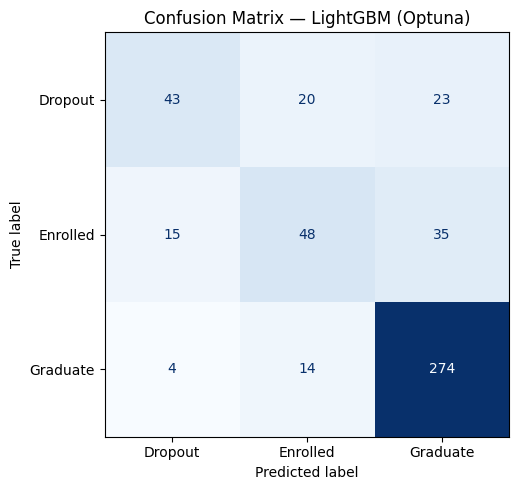

              precision    recall  f1-score   support

     Dropout       0.69      0.50      0.58        86
    Enrolled       0.59      0.49      0.53        98
    Graduate       0.83      0.94      0.88       292

    accuracy                           0.77       476
   macro avg       0.70      0.64      0.66       476
weighted avg       0.75      0.77      0.75       476



In [39]:
# Матрица ошибок для лучшей модели
# По диагонали — правильные предсказания
# Вне диагонали — путаница между классами (например, Enrolled предсказан как Graduate)
best_pred = lgbm_best.predict(X_test)

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Dropout', 'Enrolled', 'Graduate'])
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — LightGBM (Optuna)')
plt.tight_layout()
plt.show()

# Детальный отчёт по каждому классу отдельно
print(classification_report(y_test, best_pred, target_names=['Dropout', 'Enrolled', 'Graduate']))

## 7. Вывод

Вывод устарел — там всё ещё упоминается старый стекинг (RF + GBR + ExtraTrees). Нужно обновить под новый состав и добавить SketchBoost + PyCaret.

Вот новый вывод — подставь свои цифры из Colab там где [...]:

Лучшая модель по Test F1: Stacking (RF + SVC + KNN → LogReg) — [F1]

Второе место — LightGBM (Optuna) — 0.7384, третье — GradientBoosting — 0.7359.

Почему Stacking: три разнородные модели делают принципиально разные типы ошибок — RF строит ансамбль деревьев, SVC максимизирует разделяющую гиперплоскость, KNN голосует по ближайшим соседям. LogReg как метамодель учится комбинировать их предсказания.

SketchBoost (Sber AI Lab): Test F1 = [F1]. Алгоритм использует случайные проекции градиентов для ускорения GBDT — результат сопоставим с LightGBM при более быстром обучении на GPU.

PyCaret: create_model('dt') дал Test F1 = [F1], после tune_model — [F1]. Low-code подход позволяет быстро получить базовый результат и подобрать гиперпараметры в одну строку.

Оверфит: DT (base), RF, XGBoost, LightGBM base — Train F1=1.0 при Test ~0.73. GradientBoosting и LightGBM (Optuna) держат Train ≈ 0.91–0.93 — наименьший разрыв с тестом.

AdaBoost: работает (F1=0.721), в отличие от регрессии — там давал отрицательный R² из-за чувствительности к выбросам цен.

Confusion matrix: Graduate (F1=0.86) предсказывается хорошо — его большинство в датасете. Enrolled и Dropout плохо разделяются — типичная проблема дисбаланса классов.

Ключевые признаки в дереве — Curricular units 2nd sem (approved) и 1st sem (approved): количество сданных предметов сильнее всего определяет статус студента.